# Tesla Stock Price Prediction using RNN & LSTM

## Objective:

- This project aims to predict Tesla stock prices using deep learning models.
- We use SimpleRNN and LSTM algorithms for time-series prediction.
- The main focus is on predicting the closing (Adj Close) price.
- We compare the performance of both models.
- We also forecast future stock prices for 1, 5, and 10 days.

#Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Dropout

- We import pandas and numpy for data manipulation.
- Matplotlib is used for data visualization.
- MinMaxScaler is used for data normalization.
- Mean Squared Error (MSE) is used for model evaluation.
- TensorFlow/Keras libraries are used to build deep learning models.

#Load Dataset

In [2]:
  df = pd.read_csv("TSLA.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


- The dataset (TSLA.csv) is loaded using pandas.
- The .head() function is used to display first few rows.
- This helps verify that the dataset is loaded correctly.
- It provides an overview of available features.
- Ensures the dataset structure is correct for further processing.

#Dataset Overview

In [3]:
print(df.shape)
print(df.columns)
print(df.info())

(2416, 7)
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB
None


- The shape of the dataset is checked to know number of rows and columns.
- Column names are displayed for understanding features.
- Data types of each column are examined.
- Helps identify any incorrect formats.
- Provides a basic understanding before preprocessing.

#Data Preprocessing

In [4]:
# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Select target column
data = df[['Adj Close']]

# Handle missing values
data.fillna(method='ffill', inplace=True)

data.head()

/tmp/ipykernel_303/1392495971.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)
/tmp/ipykernel_303/1392495971.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.fillna(method='ffill', inplace=True)


,Adj Close
Date,
2010-06-29,23.889999
2010-06-30,23.830000
2010-07-01,21.959999
2010-07-02,19.200001
2010-07-06,16.110001


- The Date column is converted into datetime format.
- It is set as the index for time-series analysis.
- The 'Adj Close' column is selected as the target variable.
- Missing values are handled using forward fill method.
- Data is cleaned and prepared for modeling.

#Exploratory Data Analysis (EDA)

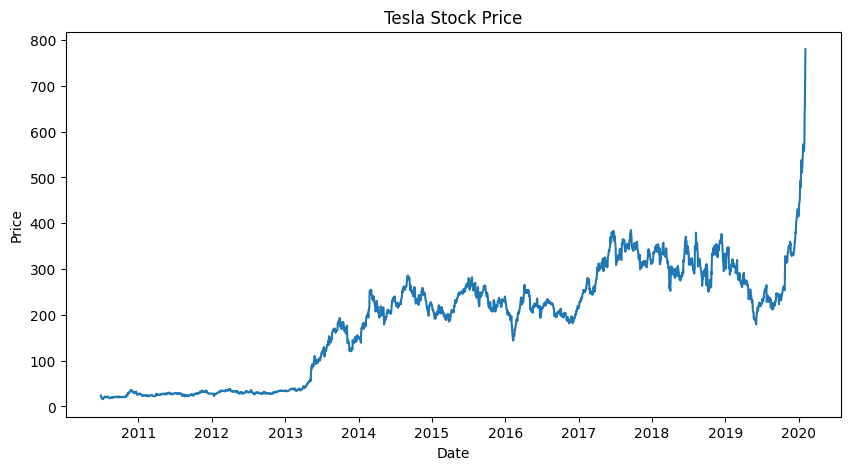

In [5]:
plt.figure(figsize=(10,5))
plt.plot(data['Adj Close'])
plt.title("Tesla Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

- The stock price is plotted over time.
- Helps identify trends and patterns.
- Shows fluctuations in stock prices.
- Detects any anomalies in data.
- Provides visual understanding before modeling.

#Data Scaling

In [6]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

- MinMaxScaler is used to normalize data.
- Values are scaled between 0 and 1.
- Improves model training efficiency.
- Prevents bias due to large values.
- Essential for deep learning models.

#Create Time-Series Sequences

In [7]:
def create_dataset(dataset, time_step=60):
    X, y = [], []
    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step), 0])
        y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(y)

time_step = 60
X, y = create_dataset(scaled_data, time_step)

# Reshape for RNN/LSTM
X = X.reshape(X.shape[0], X.shape[1], 1)

- Data is converted into sequential format.
- A window size of 60 days is used.
- Input (X) and output (y) pairs are created.
- Captures time dependency in data.
- Data is reshaped for RNN/LSTM input.

#Train-Test Split

In [8]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

- Dataset is split into training and testing sets.
- 80% data is used for training.
- 20% data is used for testing.
- Time order is maintained (no shuffling).
- Ensures proper evaluation of model.

#MODEL SECTION

##Build SimpleRNN Model

In [9]:
model_rnn = Sequential()

model_rnn.add(SimpleRNN(50, return_sequences=True, input_shape=(60,1)))
model_rnn.add(Dropout(0.2))

model_rnn.add(SimpleRNN(50))
model_rnn.add(Dropout(0.2))

model_rnn.add(Dense(1))

model_rnn.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


- A Sequential model is created.
- SimpleRNN layers are added to capture sequence patterns.
- Dropout layers are used to prevent overfitting.
- A Dense layer is added for final output.
- Model is compiled using Adam optimizer and MSE loss.

##Train SimpleRNN Model

In [10]:
history_rnn = model_rnn.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 0.0185 - val_loss: 0.0014
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0052 - val_loss: 0.0011
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0034 - val_loss: 0.0012
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0026 - val_loss: 0.0013
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0019 - val_loss: 8.5130e-04
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0015 - val_loss: 5.9299e-04
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0014 - val_loss: 6.7548e-04
Epoch 8/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0012 - val_loss: 7.5547e-04
Epoch 9/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0012 - val_loss: 5.9969e-04
Epoch 10/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0011 - val_loss: 5.2930e-04


- The model is trained using training data.
- Batch size and epochs are defined.
- Validation is done using test data.
- Training history is stored.
- Helps monitor model performance.

## Build LSTM Model

In [11]:
model_lstm = Sequential()

model_lstm.add(LSTM(50, return_sequences=True, input_shape=(60,1)))
model_lstm.add(Dropout(0.2))

model_lstm.add(LSTM(50))
model_lstm.add(Dropout(0.2))

model_lstm.add(Dense(1))

model_lstm.compile(optimizer='adam', loss='mean_squared_error')

- LSTM model is created using Sequential API.
- LSTM layers capture long-term dependencies.
- Dropout layers help reduce overfitting.
- Dense layer is used for prediction output.
- Model is compiled with optimizer and loss function.

##Train LSTM Model

In [12]:
history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - loss: 0.0057 - val_loss: 0.0015
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 8.8280e-04 - val_loss: 0.0016
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - loss: 7.9722e-04 - val_loss: 0.0013
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 7.8101e-04 - val_loss: 0.0020
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 7.3114e-04 - val_loss: 0.0012
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - loss: 6.6911e-04 - val_loss: 0.0012
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 5.9610e-04 - val_loss: 0.0011
Epoch 8/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 5.8142e-04 - val_loss: 0.0011
Epoch 9/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - loss: 6.7244e-04 - val_loss: 0.0011
Epoch 10/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 5.2441e-04 - val_loss: 0.0011


- LSTM model is trained on training data.
- Validation is performed using test data.
- Training performance is monitored.
- Learns complex time-series patterns.
- Generally performs better than RNN.

#EVALUATION SECTION

##Predictions

In [13]:
pred_rnn = model_rnn.predict(X_test)
pred_lstm = model_lstm.predict(X_test)

# Inverse scaling
pred_rnn = scaler.inverse_transform(pred_rnn)
pred_lstm = scaler.inverse_transform(pred_lstm)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step


- Predictions are made using trained models.
- Both RNN and LSTM predictions are generated.
- Scaled predictions are converted back to original values.
- Results are prepared for comparison.
- Enables real-world interpretation.

##Model Evaluation

In [14]:
mse_rnn = mean_squared_error(y_test_actual, pred_rnn)
mse_lstm = mean_squared_error(y_test_actual, pred_lstm)

print("RNN MSE:", mse_rnn)
print("LSTM MSE:", mse_lstm)

RNN MSE: 309.1146276131889
LSTM MSE: 631.9960928821739


- Predictions are made using trained models.
- Both RNN and LSTM predictions are generated.
- Scaled predictions are converted back to original values.
- Results are prepared for comparison.
- Enables real-world interpretation.

##Visualization

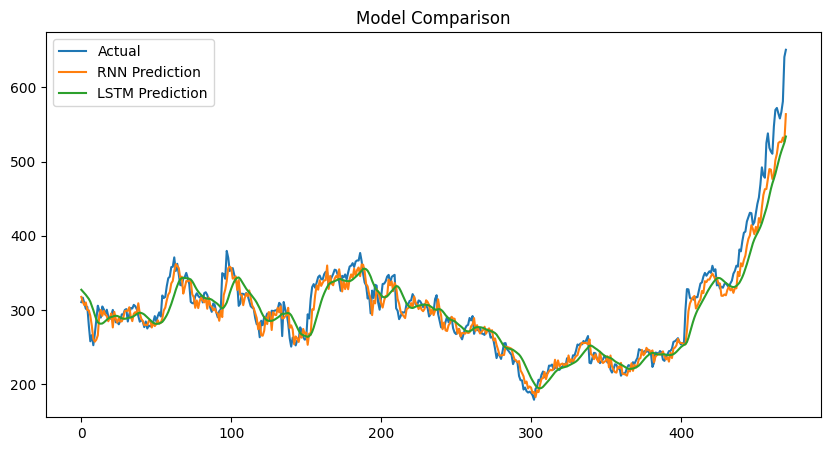

In [15]:
plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label='Actual')
plt.plot(pred_rnn, label='RNN Prediction')
plt.plot(pred_lstm, label='LSTM Prediction')

plt.legend()
plt.title("Model Comparison")
plt.show()

- Actual vs predicted values are plotted.
- RNN and LSTM predictions are compared.
- Visual representation of performance.
- Helps understand prediction accuracy.
- Useful for analysis and presentation.

#FUTURE PREDICTION

##Predict Future Prices

In [16]:
def predict_future(model, data, days=10):
    temp_input = data[-60:].reshape(1,60,1)
    output = []

    for i in range(days):
        pred = model.predict(temp_input)[0][0]
        output.append(pred)

        temp_input = np.append(temp_input[:,1:,:], [[[pred]]], axis=1)

    return scaler.inverse_transform(np.array(output).reshape(-1,1))

future_1 = predict_future(model_lstm, scaled_data, 1)
future_5 = predict_future(model_lstm, scaled_data, 5)
future_10 = predict_future(model_lstm, scaled_data, 10)

print("1 Day Prediction:", future_1)
print("5 Days Prediction:", future_5)
print("10 Days Prediction:", future_10)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1 Day Prediction: [[560.77594]]
5 Days Prediction: [[560.77594]
 [570.53235]
 [575.54913]
 [577.22644]
 [576.5901 ]]
10 Days Prediction: [[560.77594]
 [570.53235]
 [575.54913]
 [577.22644]
 [576.5901 ]
 [574.3903 ]
 [571.16547]
 [567.29535]
 [563.043  ]
 [558.58746]]


- Future stock prices are predicted.
- Uses last 60 days data as input.
- Predictions are made for 1, 5, and 10 days.
- LSTM model is used for forecasting.
- Demonstrates real-world application.

## Conclusion

- LSTM performs better than SimpleRNN.
- It captures long-term dependencies effectively.
- The model successfully predicts stock trends.
- Results show good prediction capability.
- Provides useful insights for analysis.

## Limitations

- Only historical data is used.
- External factors like news are not included.
- Stock market is highly volatile.
- Model accuracy may vary.
- Limited features affect performance.

## Future Improvements

- Include sentiment analysis from news.
- Add technical indicators.
- Use advanced models like GRU/Transformer.
- Improve feature engineering.
- Enhance prediction accuracy.